<a href="https://colab.research.google.com/github/e23189uop/Statistical-Learning-e23189/blob/main/assignment%2307_e23189/assignment07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Q. Analytical Derivation

For a linear-Gaussian state-space model, linear transformations of Gaussian random variables remain Gaussian. We assume the standard definitions where the process noise $w_{k-1} \sim \mathscr{N}(0, \Sigma_p)$ and measurement noise $z_k \sim \mathscr{N}(0, \Sigma_m)$ are zero-mean and independent of the state.

**1. Show that $x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$**
The *a priori* state estimate is given by $x^{-}_k = A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}$.
Taking the expectation (mean):


$$E[x_k^-] = A_{k-1}E[x^+_{k-1}] + G_{k-1}E[w_{k-1}]$$

$$m_k^- = A_{k-1}m_{k-1} + G_{k-1}(0) = A_{k-1}m_{k-1}$$


Taking the variance:


$$Var(x_k^-) = Var(A_{k-1}x^+_{k-1} + G_{k-1}w_{k-1})$$


Since $x^+_{k-1}$ and $w_{k-1}$ are independent:


$$P_k^- = A_{k-1}Var(x^+_{k-1})A_{k-1}^T + G_{k-1}Var(w_{k-1})G_{k-1}^T$$

$$P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T$$

**2. Show that $y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$**
The measurement prediction is $y^{-}_k = H_k\,x^{-}_k + z_k$.
Mean:


$$E[y_k^-] = H_k E[x_k^-] + E[z_k] = H_k m_k^- + 0 = H_k m_k^-$$


Variance:


$$Var(y_k^-) = H_k Var(x_k^-)H_k^T + Var(z_k) = H_k P_k^- H_k^T + \Sigma_m$$

**3. Show the joint distribution of $[x_k^-, y^{-}_k]^T$**
To find the joint covariance, we need the cross-covariance between $x_k^-$ and $y_k^-$:


$$Cov(x_k^-, y_k^-) = E[(x_k^- - m_k^-)(y_k^- - H_k m_k^-)^T]$$


Substitute $y_k^- = H_k x_k^- + z_k$:


$$Cov(x_k^-, y_k^-) = E[(x_k^- - m_k^-)(H_k(x_k^- - m_k^-) + z_k)^T]$$

$$Cov(x_k^-, y_k^-) = E[(x_k^- - m_k^-)(x_k^- - m_k^-)^T]H_k^T + E[(x_k^- - m_k^-)z_k^T]$$


Since state and measurement noise are independent, the second term is zero. Thus:


$$Cov(x_k^-, y_k^-) = P_k^- H_k^T$$


Combining this with the marginal distributions derived in steps 1 and 2, the joint Gaussian distribution is:


$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right)$$

**4. Show the posterior distribution $x^{+}_k$**
Using standard multivariate Gaussian conditioning formulas, if $\begin{bmatrix} X \\ Y \end{bmatrix} \sim \mathscr{N}\left(\begin{bmatrix} \mu_X \\ \mu_Y \end{bmatrix}, \begin{bmatrix} \Sigma_{XX} & \Sigma_{XY} \\ \Sigma_{YX} & \Sigma_{YY} \end{bmatrix}\right)$, then $X|Y = y \sim \mathscr{N}(\mu_{X|Y}, \Sigma_{X|Y})$ where:


$$\mu_{X|Y} = \mu_X + \Sigma_{XY}\Sigma_{YY}^{-1}(y - \mu_Y)$$

$$\Sigma_{X|Y} = \Sigma_{XX} - \Sigma_{XY}\Sigma_{YY}^{-1}\Sigma_{YX}$$


Substituting $X = x_k^-$, $Y = y_k^-$, and $y = y^{\mathrm{obs}}_{k}$:


$$m_k = m_k^- + P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1} (y^{\mathrm{obs}}_{k} - H_k m_k^-)$$


Letting Kalman Gain $K_k \triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$, this simplifies to:


$$m_k = m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-)$$


For the covariance:


$$P_k = P_k^- - P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1} H_k P_k^-$$

$$P_k = P_k^- - K_k H_k P_k^- = (I - K_k H_k) P_k^-$$

**5. Find Conditional Expectation and Variance**
Based on the posterior distribution established in step 4:


$$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}] = m_k$$

$$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) = P_k$$

---

## Q. 1-D Example

This section applies the analytical derivations to a 1D scalar model where matrices become scalar variables ($A \to a$, $H \to h$, $G \to 1$, $\Sigma_p \to q$, $\Sigma_m \to r$).

**1. Show the prediction steps**
Substituting scalar values into $m_k^- = A_{k-1}m_{k-1}$ and $P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T$ yields:


$$m_k^- = a\,m_{k-1}$$

$$P_k^- = a (P_{k-1}) a + (1) q (1) = a^2 P_{k-1} + q$$

**2. Show the update steps**
Substituting scalars into the Kalman gain and update equations:


$$S_k = h (P_k^-) h + r = h^2 P_k^- + r$$

$$K_k = P_k^- h (S_k)^{-1} = \frac{P_k^- h}{S_k}$$

$$m_k = m_k^- + K_k (y^{\mathrm{obs}}_k - h\,m_k^-)$$

$$P_k = (1 - K_k h) P_k^- = \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^-$$

**3. Predictive measurement distribution**
Using the derivation from Q1.2 ($y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$), for scalars:


$$p(y^-_k | Y_{k-1}) = \mathscr{N}\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr)$$

**4. Posterior-predictive measurement distribution**
After incorporating the observation $y_k$, our best estimate of the state becomes $x_k \sim \mathscr{N}(m_k, P_k)$. The measurement equation applied to this updated state gives:


$$E[y_k \mid Y_k] = h E[x_k \mid Y_k] = h m_k$$

$$Var(y_k \mid Y_k) = h^2 Var(x_k \mid Y_k) + r = h^2 P_k + r$$

$$p(y^-_k \mid Y_k) = \mathscr{N}\bigl(h\,m_k,\; h^2 P_k + r\bigr)$$

**5. Python Animation for Prior and Posterior**



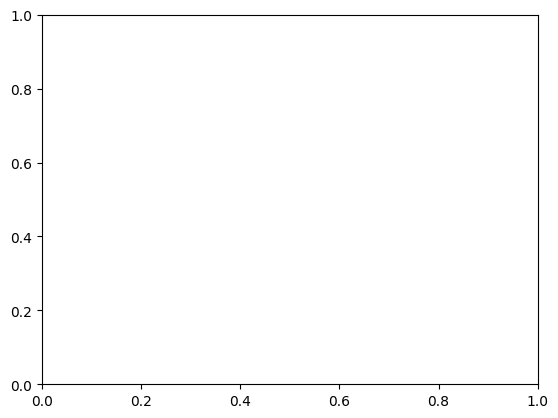

In [5]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib.animation as animation

# Parameters
a, q, h, r = 1.0, 0.1, 1.0, 0.5
m_prev, P_prev = 0.0, 1.0
observations = [1.2, 2.1, 2.8, 3.9, 4.2]

fig, ax = plt.subplots()
x_axis = np.linspace(-3, 8, 1000)

def animate(i):
    global m_prev, P_prev
    ax.clear()

    # Prediction
    m_minus = a * m_prev
    P_minus = a**2 * P_prev + q

    # Update
    y_obs = observations[i]
    S = h**2 * P_minus + r
    K = (P_minus * h) / S
    m_curr = m_minus + K * (y_obs - h * m_minus)
    P_curr = (1 - K * h) * P_minus

    # Plotting
    prior = norm.pdf(x_axis, m_minus, np.sqrt(P_minus))
    posterior = norm.pdf(x_axis, m_curr, np.sqrt(P_curr))

    ax.plot(x_axis, prior, label='Prior (Prediction)', color='blue', linestyle='--')
    ax.plot(x_axis, posterior, label='Posterior (Update)', color='red')
    ax.axvline(y_obs, color='green', label='Observation', linestyle=':')
    ax.set_title(f"Step {i+1}")
    ax.legend()
    ax.set_ylim(0, 1.5)

    m_prev, P_prev = m_curr, P_curr

ani = animation.FuncAnimation(fig, animate, frames=len(observations), repeat=False)
plt.show()




## Q. 2D-Position Estimation

### Part A: Matrix Derivations

The state is defined as $x_k = [p_x(k), p_y(k), v_x(k), v_y(k)]^T$ and the measurement as $y_k = [p_x^{\mathrm{meas}}(k), p_y^{\mathrm{meas}}(k)]^T$.

**State Transition Matrix ($A$)**
Using basic kinematics for constant velocity, position updates according to velocity over time step $\Delta t$, and velocity remains constant:


$$p_x(k) = p_x(k-1) + v_x(k-1)\Delta t$$

$$p_y(k) = p_y(k-1) + v_y(k-1)\Delta t$$

$$v_x(k) = v_x(k-1)$$

$$v_y(k) = v_y(k-1)$$


Writing this in matrix form $x_k = A x_{k-1}$ produces:


$$A = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

**Observation Matrix ($H$)**
The system only measures the position components $p_x$ and $p_y$, ignoring the velocity components. Therefore, $H$ extracts the first two elements of $x_k$:


$$H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}$$

**Process Noise Gain Matrix ($G$)**
Assuming the process noise $w_k$ represents random accelerations $(a_x, a_y)$, the effect of acceleration over $\Delta t$ on position is $\frac{1}{2}a\Delta t^2$ and on velocity is $a\Delta t$. Thus, mapping the 2D acceleration noise onto the 4D state vector gives:


$$G = \begin{bmatrix} \frac{1}{2}\Delta t^2 & 0 \\ 0 & \frac{1}{2}\Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix}$$

### Part B: Python Filtering Method


In [2]:

import numpy as np

class KalmanFilter2D:
    def __init__(self, dt, sigma_p, sigma_m):
        # State Transition Matrix (A)
        self.A = np.array([
            [1, 0, dt, 0],
            [0, 1, 0, dt],
            [0, 0, 1, 0],
            [0, 0, 0, 1]
        ])

        # Observation Matrix (H)
        self.H = np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0]
        ])

        # Process Noise Gain Matrix (G)
        self.G = np.array([
            [0.5 * dt**2, 0],
            [0, 0.5 * dt**2],
            [dt, 0],
            [0, dt]
        ])

        # Noise Covariances
        self.Q = self.G @ np.diag([sigma_p**2, sigma_p**2]) @ self.G.T
        self.R = np.diag([sigma_m**2, sigma_m**2])

        # Initial State (m) and Covariance (P)
        self.m = np.zeros(4)
        self.P = np.eye(4) * 1000  # High initial uncertainty

    def predict(self):
        # A priori state and covariance
        self.m = self.A @ self.m
        self.P = self.A @ self.P @ self.A.T + self.Q
        return self.m[:2]

    def update(self, measurement):
        # Measurement update
        y_obs = np.array(measurement)
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)

        self.m = self.m + K @ (y_obs - self.H @ self.m)
        self.P = (np.eye(4) - K @ self.H) @ self.P

        return self.m[:2]

    def filter_gps_data(self, gps_measurements):
        """
        Processes a sequence of [(x1,y1), (x2,y2), ...] observations.
        """
        filtered_positions = []
        for z in gps_measurements:
            self.predict()
            pos = self.update(z)
            filtered_positions.append(pos)
        return np.array(filtered_positions)

